# Underwater Garbage Detection — Day 2: Dataset Exploration

**Dataset**: TrashCAN<br>
**Project:** Underwater Garbage Detection<br>

## 1. Mount Drive & Extract Dataset

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive/INTERNSHIPWORK/')

['dataset',
 'dataset.zip',
 'UnderWater_Garbage_Visual_EDA.ipynb',
 'UnderWater_Garbage_Day3 work .ipynb',
 'UnderwaterGarbageDetection.ipynb',
 'UnderWater_Garbage_Day9work_.ipynb',
 'UnderWater_Garbage_Day12.ipynb',
 'UnderWater_Garbage_Day11.ipynb',
 'UnderWater_Garbage_Day10.ipynb']

In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/INTERNSHIPWORK/dataset.zip'
extract_path = '/content/TrashCAN'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## 2. Explore Folder Structure

In [4]:
import os

for root, dirs, files in os.walk('/content/TrashCAN'):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

/content/TrashCAN
Folders: ['dataset']
Files: []
--------------------------------------------------
/content/TrashCAN/dataset
Folders: ['scripts', 'original_data', 'instance_version', 'material_version']
Files: ['README.txt']
--------------------------------------------------
/content/TrashCAN/dataset/scripts
Folders: []
Files: ['trash_can_coco.py']
--------------------------------------------------
/content/TrashCAN/dataset/original_data
Folders: ['annotations', 'images']
Files: ['README.txt']
--------------------------------------------------
/content/TrashCAN/dataset/original_data/annotations
Folders: []
Files: ['vid_000122_frame0000065.jpg.json', 'vid_000293_frame0000010.jpg.json', 'vid_000155_frame0000002.jpg.json', 'vid_000143_frame0000057.jpg.json', 'vid_000041_frame0000002.jpg.json']
--------------------------------------------------
/content/TrashCAN/dataset/original_data/images
Folders: []
Files: ['vid_000440_frame0000110.jpg', 'vid_000295_frame0000009.jpg', 'vid_000285_frame

In [5]:
dataset_path = '/content/TrashCAN/dataset'
material_path = os.path.join(dataset_path, 'material_version')

print("Material version contents:")
for item in os.listdir(material_path):
    print(item)

Material version contents:
instances_train_trashcan.json
train
instances_val_trashcan.json
README.txt
val


## 3. Count Train/Val Images

In [6]:
train_path = os.path.join(material_path, 'train')
val_path = os.path.join(material_path, 'val')

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

train_images = [
    f for f in os.listdir(train_path)
    if f.lower().endswith(image_extensions)
]

val_images = [
    f for f in os.listdir(val_path)
    if f.lower().endswith(image_extensions)
]

print("===== DATASET IMAGE COUNT =====")
print("Training images   :", len(train_images))
print("Validation images :", len(val_images))
print("Total images      :", len(train_images) + len(val_images))

===== DATASET IMAGE COUNT =====
Training images   : 6008
Validation images : 1204
Total images      : 7212


## 4. Load COCO Annotations & Verify

In [7]:
import json

train_json_path = os.path.join(material_path, 'instances_train_trashcan.json')
val_json_path = os.path.join(material_path, 'instances_val_trashcan.json')

with open(train_json_path, 'r') as f:
    train_data = json.load(f)

with open(val_json_path, 'r') as f:
    val_data = json.load(f)

print("===== COCO DATASET INFORMATION =====")
print("\nTRAINING")
print("Images       :", len(train_data['images']))
print("Annotations  :", len(train_data['annotations']))
print("Categories   :", len(train_data['categories']))

print("\nVALIDATION")
print("Images       :", len(val_data['images']))
print("Annotations  :", len(val_data['annotations']))
print("Categories   :", len(val_data['categories']))

===== COCO DATASET INFORMATION =====

TRAINING
Images       : 6008
Annotations  : 9741
Categories   : 16

VALIDATION
Images       : 1204
Annotations  : 2595
Categories   : 16


### 4a. Verify JSON integrity — missing annotations / orphan references
Checks that every annotation points to a real image, and flags images that have zero annotations.

In [8]:
image_ids_in_json = {img['id'] for img in train_data['images']}
annotated_ids = {ann['image_id'] for ann in train_data['annotations']}

images_without_annotations = image_ids_in_json - annotated_ids
orphan_annotations = annotated_ids - image_ids_in_json

print("Images with zero annotations:", len(images_without_annotations))
print("Annotations pointing to missing images:", len(orphan_annotations))

if images_without_annotations:
    sample_missing = list(images_without_annotations)[:10]
    id_to_filename = {img['id']: img['file_name'] for img in train_data['images']}
    print("\nSample images with no annotations:")
    for img_id in sample_missing:
        print(" -", id_to_filename[img_id])

Images with zero annotations: 0
Annotations pointing to missing images: 0


## 5. Classes — All 16 Categories

In [9]:
categories = train_data['categories']

for cat in categories:
    print(cat['id'], "→", cat['name'])

1 → rov
2 → plant
3 → animal_fish
4 → animal_starfish
5 → animal_shells
6 → animal_crab
7 → animal_eel
8 → animal_etc
9 → trash_etc
10 → trash_fabric
11 → trash_fishing_gear
12 → trash_metal
13 → trash_paper
14 → trash_plastic
15 → trash_rubber
16 → trash_wood


### 5a. Identify garbage vs non-garbage classes
The TrashCAN dataset mixes ROV, marine life, and plant categories in with the actual trash categories.
Only the `trash_*` classes are garbage — the rest (`rov`, `plant`, `animal_*`) are not.

In [10]:
category_names = {cat['id']: cat['name'] for cat in categories}

garbage_classes = [c['name'] for c in categories if c['name'].startswith('trash_')]
non_garbage_classes = [c['name'] for c in categories if not c['name'].startswith('trash_')]

print("Garbage classes (", len(garbage_classes), "):", garbage_classes)
print("Non-garbage classes (", len(non_garbage_classes), "):", non_garbage_classes)

Garbage classes ( 8 ): ['trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']
Non-garbage classes ( 8 ): ['rov', 'plant', 'animal_fish', 'animal_starfish', 'animal_shells', 'animal_crab', 'animal_eel', 'animal_etc']


## 6. Class Distribution

In [11]:
from collections import Counter

counts = Counter(ann['category_id'] for ann in train_data['annotations'])

print("Class distribution (all 16 classes):\n")
for category_id, count in counts.most_common():
    print(category_names[category_id], "→", count)

Class distribution (all 16 classes):

rov → 2653
trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
animal_fish → 611
plant → 405
animal_starfish → 274
trash_wood → 271
animal_eel → 267
trash_fabric → 247
animal_crab → 247
animal_etc → 180
animal_shells → 171
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


### 6a. Garbage-only class distribution
Same data, filtered to only the garbage (`trash_*`) classes — this is what actually matters for the detection task.

In [12]:
garbage_ids = {c['id'] for c in categories if c['name'].startswith('trash_')}

garbage_counts = Counter(
    ann['category_id'] for ann in train_data['annotations']
    if ann['category_id'] in garbage_ids
)

print("Garbage-only class distribution:\n")
for cid, count in garbage_counts.most_common():
    print(category_names[cid], "→", count)

Garbage-only class distribution:

trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
trash_wood → 271
trash_fabric → 247
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


## 7. Visualize Sample Images

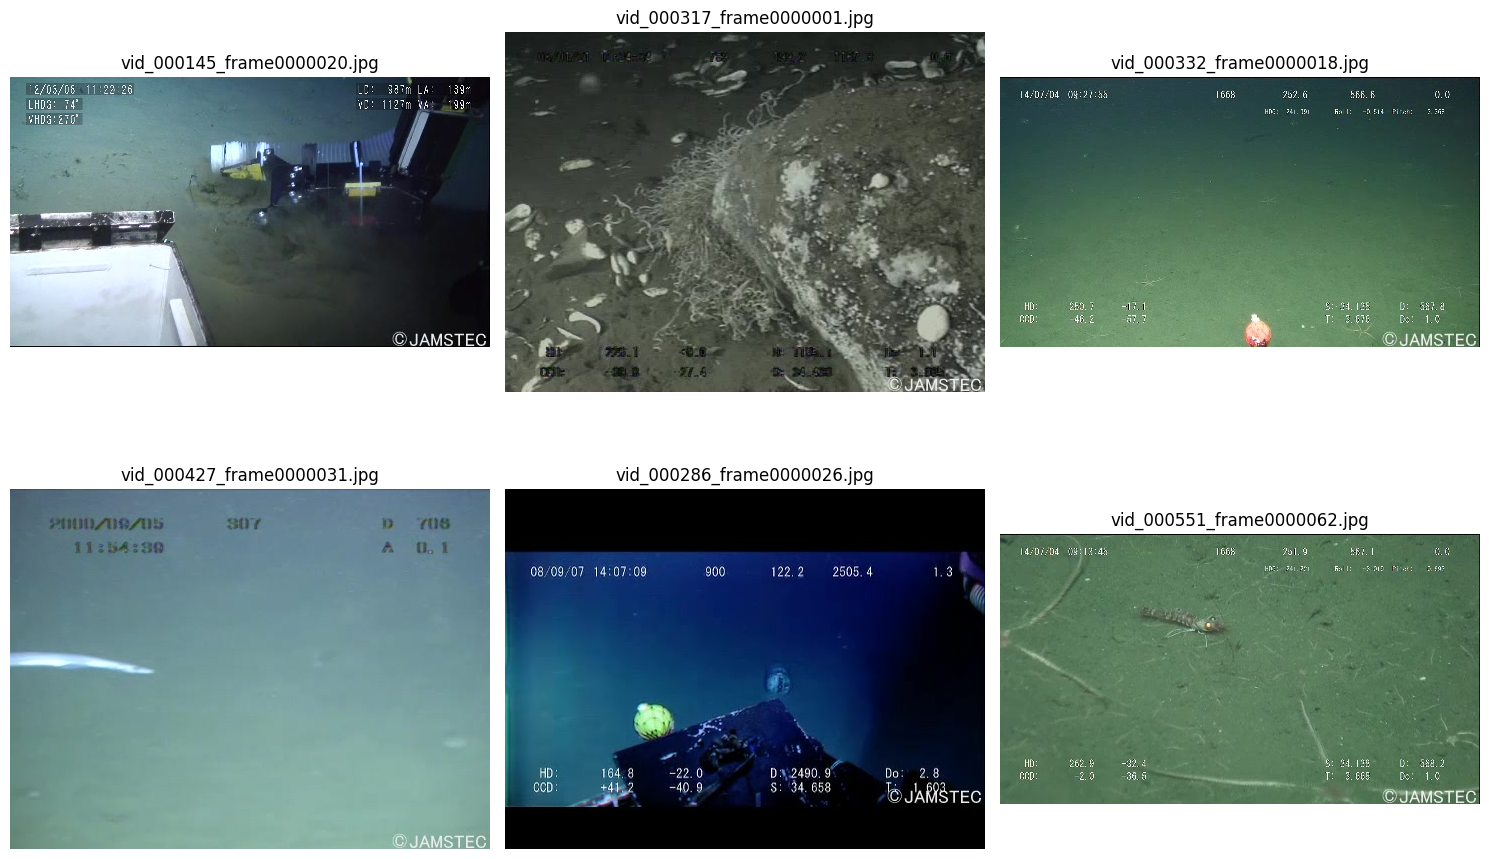

In [13]:
import random
from PIL import Image
import matplotlib.pyplot as plt

train_folder = os.path.join(material_path, 'train')

images = [
    f for f in os.listdir(train_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

sample_images = random.sample(images, min(6, len(images)))

plt.figure(figsize=(15, 10))

for i, filename in enumerate(sample_images):
    img_path = os.path.join(train_folder, filename)
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Visualize Annotations / Bounding Boxes
Actually draws the bounding boxes on an image, instead of just printing coordinates.

In [14]:
image_info = train_data['images'][0]
image_id = image_info['id']
file_name = image_info['file_name']

image_annotations = [
    ann for ann in train_data['annotations']
    if ann['image_id'] == image_id
]

print("Image ID:", image_id)
print("File:", file_name)
print("Number of objects:", len(image_annotations))

Image ID: 1
File: vid_000421_frame0000005.jpg
Number of objects: 1


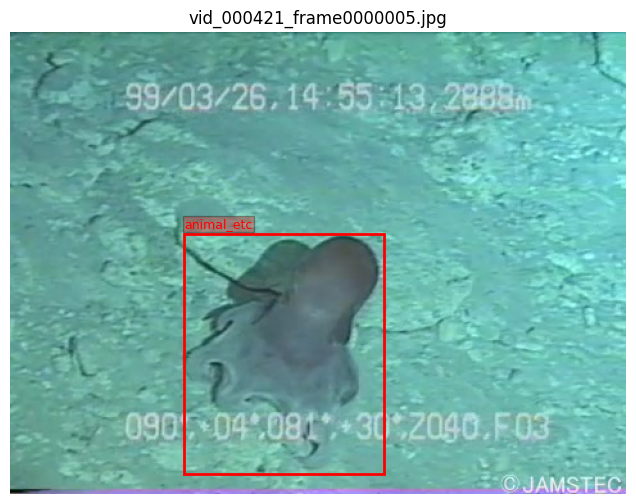

In [15]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(8, 6))
img_path = os.path.join(train_folder, file_name)
img = Image.open(img_path)
ax.imshow(img)

for ann in image_annotations:
    x, y, w, h = ann['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 5, category_names[ann['category_id']], color='red', fontsize=9,
            bbox=dict(facecolor='red', alpha=0.3, pad=1))

plt.axis('off')
plt.title(file_name)
plt.show()

## 9. Check Corrupted Images

In [16]:
bad_images = []

for filename in images:
    path = os.path.join(train_folder, filename)
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_images.append(filename)

print("Total images:", len(images))
print("Corrupted images:", len(bad_images))

if bad_images:
    print("Bad files:")
    print(bad_images[:20])

Total images: 6008
Corrupted images: 0


## 10. Check Image Resolutions

In [17]:
resolution_counts = Counter()

for filename in images:
    path = os.path.join(train_folder, filename)
    try:
        with Image.open(path) as img:
            resolution_counts[img.size] += 1
    except Exception:
        pass

print("Most common resolutions:\n")
for resolution, count in resolution_counts.most_common(10):
    print(resolution, "→", count)

Most common resolutions:

(480, 360) → 3008
(480, 270) → 3000


In [18]:
# Compare image files with image entries in the COCO JSON.
# basename() makes the check robust to paths stored inside the JSON.

json_image_names = {
    os.path.basename(img['file_name'])
    for img in train_data['images']
}

actual_image_names = set(train_images)

images_without_json_entry = actual_image_names - json_image_names
json_entries_without_image = json_image_names - actual_image_names

print("===== MISSING / UNMATCHED ANNOTATION CHECK =====")
print("Training image files              :", len(actual_image_names))
print("COCO image entries                :", len(json_image_names))
print("Images without COCO image entry   :", len(images_without_json_entry))
print("JSON entries without image file   :", len(json_entries_without_image))

if images_without_json_entry:
    print("\nImages without COCO entries (first 20):")
    for name in sorted(images_without_json_entry)[:20]:
        print(" -", name)

if json_entries_without_image:
    print("\nJSON entries without image files (first 20):")
    for name in sorted(json_entries_without_image)[:20]:
        print(" -", name)

if not images_without_json_entry and not json_entries_without_image:
    print("All training image files have matching COCO image entries.")


===== MISSING / UNMATCHED ANNOTATION CHECK =====
Training image files              : 6008
COCO image entries                : 6008
Images without COCO image entry   : 0
JSON entries without image file   : 0
All training image files have matching COCO image entries.
